<a href="https://colab.research.google.com/github/Tejeshwini89/Computer-Vision/blob/main/Spatial%20Filtering%20(Image)%20%26%20Basic%20Video%20Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Please upload your image (H.jpg) and video (12469452_2160_3840_30fps.mp4)


Saving H.jpg to H.jpg


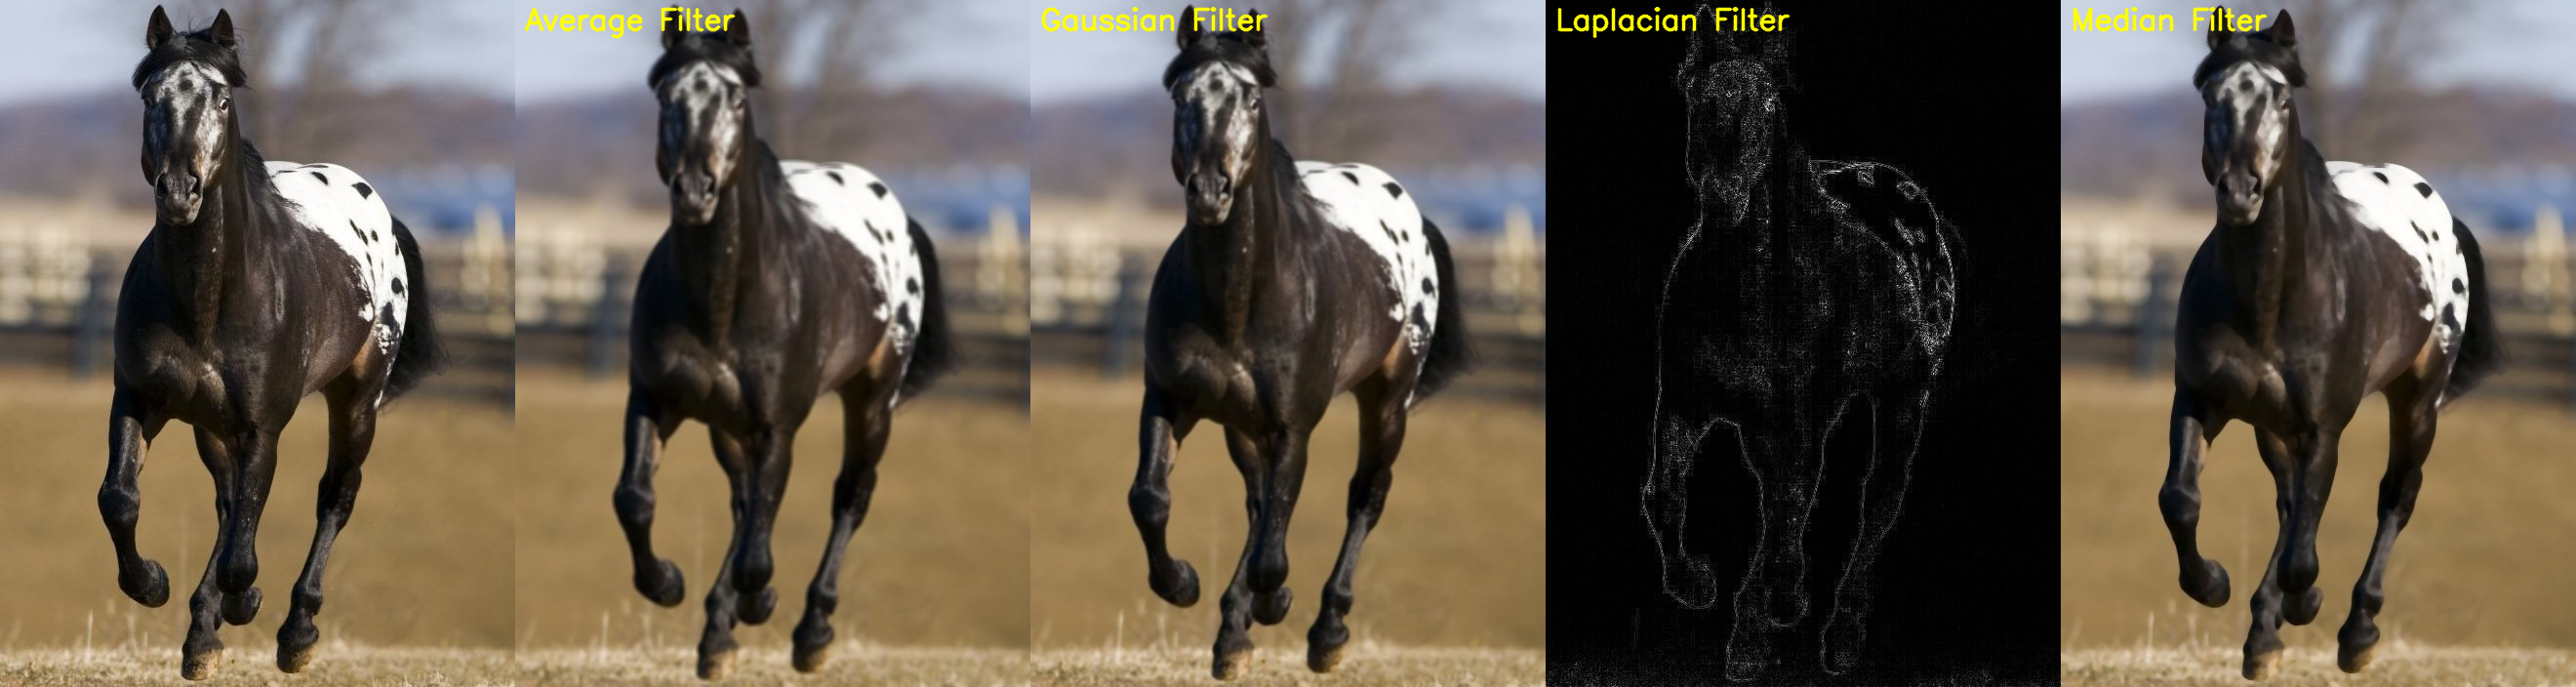

In [ ]:
# ===== Spatial Filtering (Image) & Basic Video Enhancement =====

import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

# --- Step 1: Upload Files ---
print(" Please upload your image (H.jpg) and video (12469452_2160_3840_30fps.mp4)")
uploaded = files.upload()

# --- Step 2: Image Spatial Filtering ---
img = cv2.imread('H.jpg')

if img is None:
    print("Image not found! Please ensure 'H.jpg' is uploaded.")
else:
    # Apply filters
    avg = cv2.blur(img, (5,5))                          # Average filter
    gauss = cv2.GaussianBlur(img, (5,5), 0)             # Gaussian filter
    lap = cv2.Laplacian(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.CV_64F)  # Laplacian filter
    lap = cv2.convertScaleAbs(lap)
    lap = cv2.cvtColor(lap, cv2.COLOR_GRAY2BGR)         # Convert to BGR for stacking
    med = cv2.medianBlur(img, 5)                        # Median filter

    # Add labels to each image
    def add_label(image, text):
        labeled = image.copy()
        cv2.putText(labeled, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                    1, (0, 255, 255), 2, cv2.LINE_AA)
        return labeled

    avg_l = add_label(avg, "Average Filter")
    gauss_l = add_label(gauss, "Gaussian Filter")
    lap_l = add_label(lap, "Laplacian Filter")
    med_l = add_label(med, "Median Filter")

    # Resize for uniform display
    h = min(i.shape[0] for i in [img, avg_l, gauss_l, lap_l, med_l])
    w = min(i.shape[1] for i in [img, avg_l, gauss_l, lap_l, med_l])
    img_r = cv2.resize(img, (w, h))
    avg_r = cv2.resize(avg_l, (w, h))
    gauss_r = cv2.resize(gauss_l, (w, h))
    lap_r = cv2.resize(lap_l, (w, h))
    med_r = cv2.resize(med_l, (w, h))

    # Combine all results horizontally
    combined = np.hstack((img_r, avg_r, gauss_r, lap_r, med_r))
    cv2_imshow(combined)
    cv2.imwrite('/content/image_filters_labeled.jpg', combined)




In [ ]:
# --- Step 3: Video Frame Filtering ---
cap = cv2.VideoCapture('12469452_2160_3840_30fps.mp4')

if not cap.isOpened():
    print(" Could not open video. Please ensure it is uploaded correctly.")
else:
    print("Applying filters to video frames... (ESC to stop)")
    while True:
        ret, frame = cap.read()
        if not ret:
            print(" Video ended.")
            break

        # Apply filters
        avg_v = cv2.blur(frame, (5,5))
        gauss_v = cv2.GaussianBlur(frame, (5,5), 0)
        med_v = cv2.medianBlur(frame, 5)

        # Add labels
        avg_v = add_label(avg_v, "Average")
        gauss_v = add_label(gauss_v, "Gaussian")
        med_v = add_label(med_v, "Median")

        # Combine processed frames
        combined_v = np.hstack((avg_v, gauss_v, med_v))
        cv2_imshow(combined_v)

        if cv2.waitKey(1) & 0xFF == 27:
            print(" Stopped by user.")
            break

cap.release()
cv2.destroyAllWindows()

 Could not open video. Please ensure it is uploaded correctly.
